```
ENTIRETY OF TRAIN PREPROCESSING: 
```

before
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
Group             0
GroupNum          0
CabinDeck       199
CabinNum        199
CabinSide       199
dtype: int64

Rows before: 8693
Rows after dropping nulls: 7587
after
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Group           0
GroupNum        0
CabinDeck       0
CabinNum        0
CabinSide       0
dtype: int64


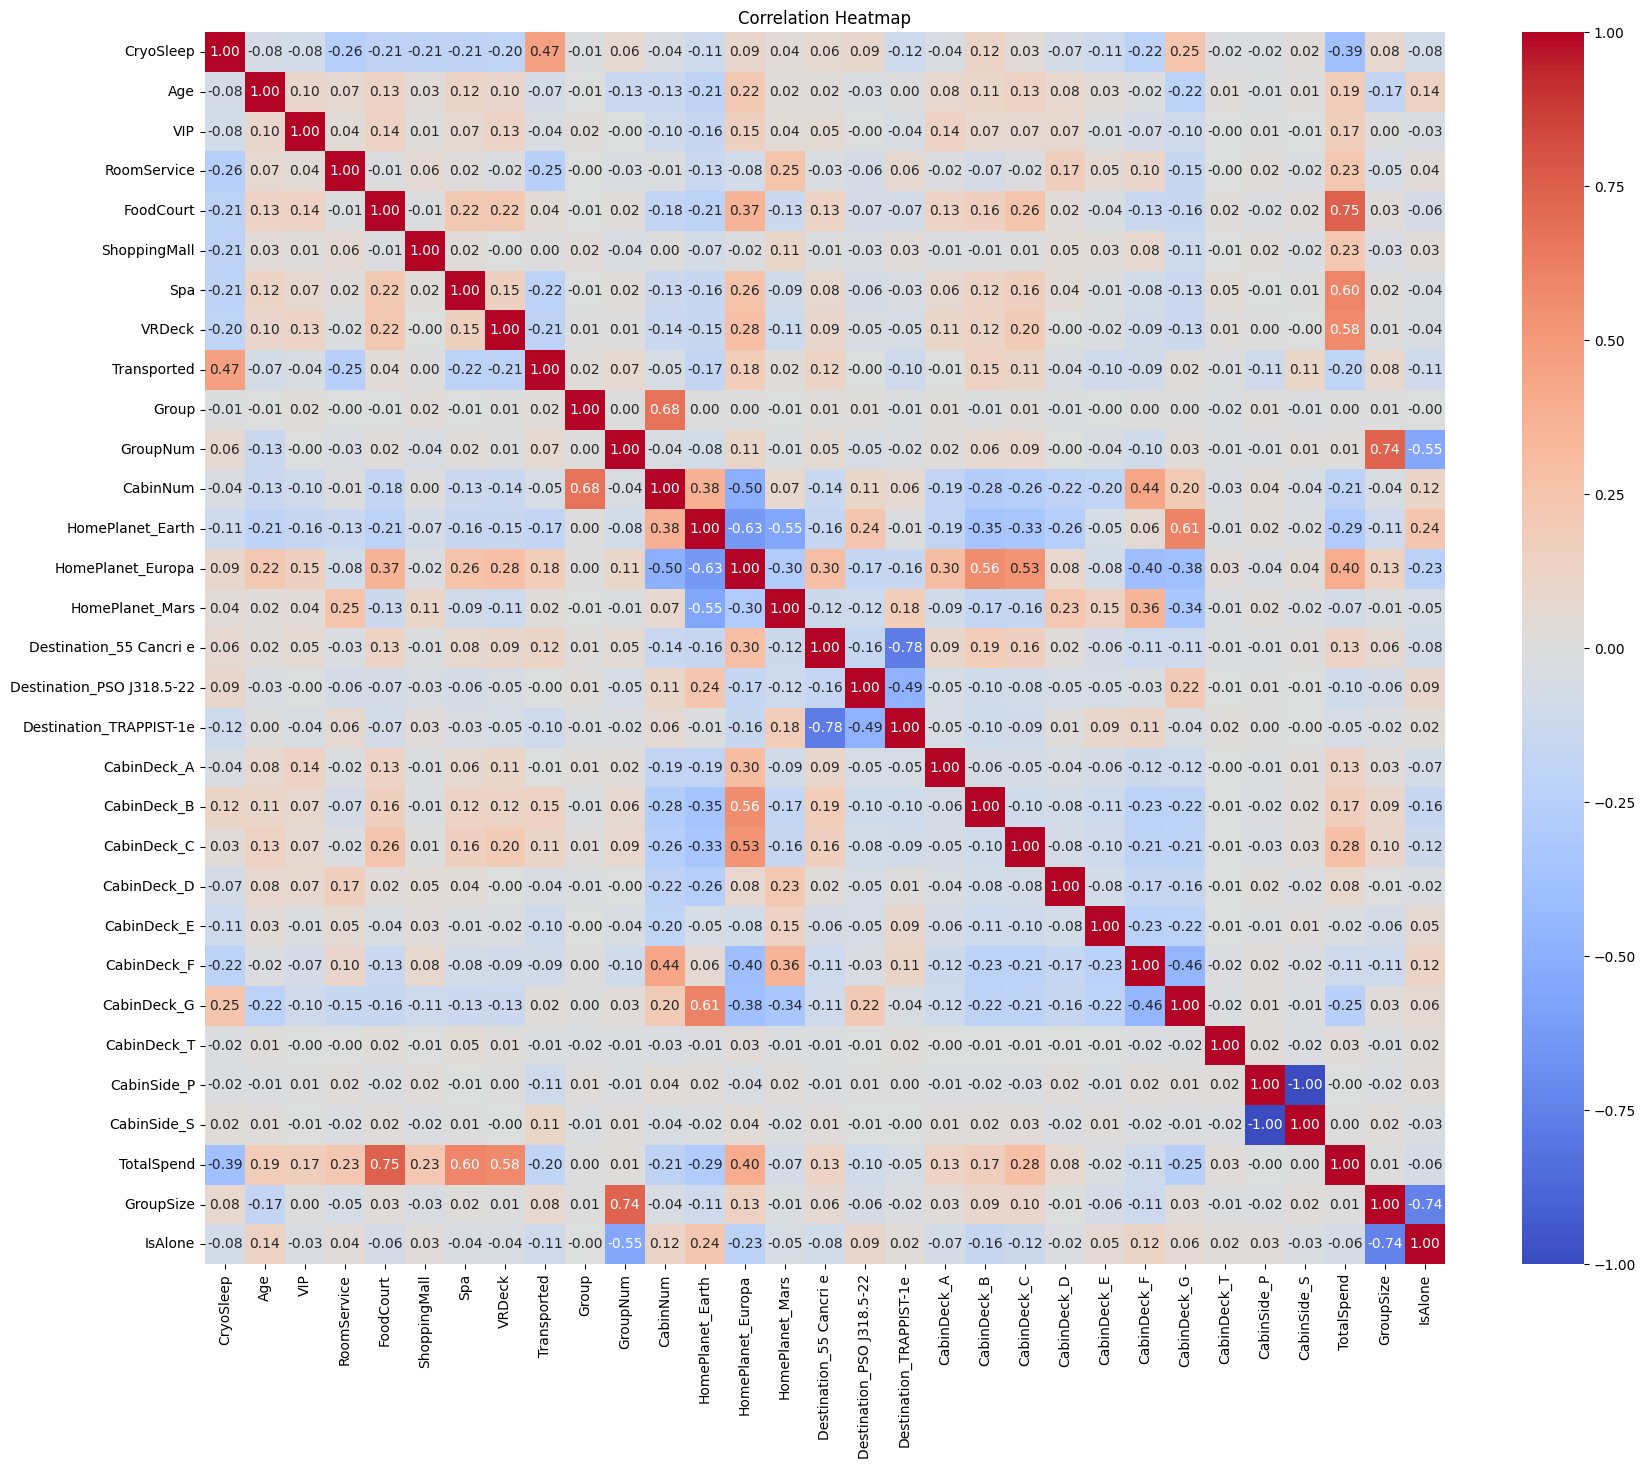

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

train = pd.read_csv("data/train.csv")

# 1
train["Transported"] = train["Transported"].astype(int)

# split passengerid
train["Group"], train["GroupNum"] = train["PassengerId"].str.split("_").str[0], train["PassengerId"].str.split("_").str[1]

# split cabin ABCDEFG/num/PS
train[["CabinDeck", "CabinNum", "CabinSide"]] = train["Cabin"].str.split("/", expand=True)
train["CabinNum"] = train["CabinNum"].astype(float)

train.drop(["PassengerId", "Cabin", "Name"], axis=1, inplace=True)

train.head()

# 2
print("before")
print(train.isnull().sum())
print()

# if homeplanet/destination/cabindeck/cabinnum empty, fill with mode of passenger travel group
for col in ["CabinDeck", "CabinSide", "HomePlanet", "Destination"]:
    group_mode = train.groupby("Group")[col].agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
    train[col] = train[col].fillna(train["Group"].map(group_mode))
    train[col] = train[col].fillna(train[col].mode()[0]) # if still null, fill with mode

spending_features = ["RoomService", "FoodCourt",  "ShoppingMall", "Spa", "VRDeck"]
# if cryosleep true, spending is 0.0
train.loc[ train["CryoSleep"] == True, spending_features ] = 0.0
# if spending not 0.0, cryosleep false
train.loc[ train[spending_features].sum(axis=1) > 0, "CryoSleep" ] = False
train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0]) # if still null, fill with mode

print("Rows before:", len(train))
print("Rows after dropping nulls:", len(train.dropna()))
# # if age or spending empty, fill median
# numerical_features = spending_features + ["Age"]
# train[numerical_features] = train[numerical_features].fillna(train[numerical_features].median())

# # if vip empty, fill mode
# train["VIP"] = train["VIP"].fillna(train["VIP"].mode()[0])

# # if cabinnum empty, fill with median
# train["CabinNum"] = train["CabinNum"].fillna(train["CabinNum"].median())
train.dropna(inplace=True)

print("after")
print(train.isnull().sum())

# 3
import seaborn as sns
import matplotlib.pyplot as plt

# encode boolean features
train["CryoSleep"] = train["CryoSleep"].astype(int)
train["VIP"] = train["VIP"].astype(int)
train["Transported"] = train["Transported"].astype(int)
train[["Group", "GroupNum"]] = train[["Group", "GroupNum"]].astype(int)

# one hot encode categorical features
train = pd.get_dummies(train, columns=["HomePlanet", "Destination", "CabinDeck", "CabinSide"])

# add extra features
train["TotalSpend"] = train["RoomService"] + train["FoodCourt"] + train["ShoppingMall"] + train["Spa"] + train["VRDeck"]
train["GroupSize"] = train.groupby("Group")["Group"].transform("count")
train["IsAlone"] = (train["GroupSize"] == 1).astype(int)

# heatmap of all features
plt.figure(figsize=(20, 16))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# scale all numerical featuresm use rfe to select features, train 
X = train.drop("Transported", axis=1)
y = train["Transported"]

# scale numerical features
float_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Age", "CabinNum"]
scaler = StandardScaler()
X[float_cols] = scaler.fit_transform(X[float_cols])

In [2]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFE
import numpy as np

# rfe feature selection using xgboost
rfe_model = XGBClassifier(n_estimators=100, random_state=0)
rfe = RFE(rfe_model, n_features_to_select=18)
rfe.fit(X, y)

features_to_keep = X.columns[rfe.support_].tolist()
print("Selected features:", features_to_keep)
X = X[features_to_keep]

# train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

# define models
xgb_model = XGBClassifier(learning_rate=0.05, max_depth=5, n_estimators=200, subsample=1.0, random_state=0, reg_alpha=0, reg_lambda=1.5, gamma=0) # optimised for 18 features
lgbm_model = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=0)
cat_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5, random_state=0, verbose=0)

# train
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

# ensemble val predictions
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]
lgbm_probs = lgbm_model.predict_proba(X_val)[:, 1]
cat_probs = cat_model.predict_proba(X_val)[:, 1]
ensemble_probs = (xgb_probs + lgbm_probs + cat_probs) / 3
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

# ensemble train predictions
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
lgbm_train_probs = lgbm_model.predict_proba(X_train)[:, 1]
cat_train_probs = cat_model.predict_proba(X_train)[:, 1]
ensemble_train_probs = (xgb_train_probs + lgbm_train_probs + cat_train_probs) / 3
ensemble_train_preds = (ensemble_train_probs >= 0.5).astype(int)

print("Train Accuracy:", accuracy_score(y_train, ensemble_train_preds))
print("Val Accuracy:", accuracy_score(y_val, ensemble_preds))
print("F1 Score:", f1_score(y_val, ensemble_preds))

# kfold cv
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
cv_scores = []

for train_idx, val_idx in kfold.split(X, y):
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_fold_train, y_fold_train)
    lgbm_model.fit(X_fold_train, y_fold_train)
    cat_model.fit(X_fold_train, y_fold_train)

    xgb_p = xgb_model.predict_proba(X_fold_val)[:, 1]
    lgbm_p = lgbm_model.predict_proba(X_fold_val)[:, 1]
    cat_p = cat_model.predict_proba(X_fold_val)[:, 1]
    fold_preds = ((xgb_p + lgbm_p + cat_p) / 3 >= 0.5).astype(int)

    cv_scores.append(accuracy_score(y_fold_val, fold_preds))

print("CV Accuracy per fold:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))

Selected features: ['CryoSleep', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_TRAPPIST-1e', 'CabinDeck_B', 'CabinDeck_C', 'CabinDeck_E', 'CabinDeck_F', 'CabinDeck_G', 'CabinSide_P', 'TotalSpend']
[LightGBM] [Info] Number of positive: 3139, number of negative: 2930
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1807
[LightGBM] [Info] Number of data points in the train set: 6069, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.517219 -> initscore=0.068902
[LightGBM] [Info] Start training from score 0.068902
Train Accuracy: 0.8907563025210085
Val Accuracy: 0.8036890645586298
F1 Score: 0.8106734434561627
[LightGBM] [Info] Number of positive: 3525, number of negative: 3303
[LightGBM] [Info] Auto-choosing col-wise multi-t

In [3]:
# fit all models on full training data
xgb_model.fit(X, y)
lgbm_model.fit(X, y)
cat_model.fit(X, y)

test = pd.read_csv("data/test.csv")

# keep passengerid for submission before dropping
test_passenger_ids = test["PassengerId"]

# split passengerid
test["Group"], test["GroupNum"] = test["PassengerId"].str.split("_").str[0], test["PassengerId"].str.split("_").str[1]

# split cabin
test[["CabinDeck", "CabinNum", "CabinSide"]] = test["Cabin"].str.split("/", expand=True)
test["CabinNum"] = test["CabinNum"].astype(float)

test.drop(["PassengerId", "Cabin", "Name"], axis=1, inplace=True)

# fill categorical nulls using group mode
for col in ["CabinDeck", "CabinSide", "HomePlanet", "Destination"]:
    group_mode = test.groupby("Group")[col].agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
    test[col] = test[col].fillna(test["Group"].map(group_mode))
    test[col] = test[col].fillna(test[col].mode()[0])

# cryosleep and spending imputation
spending_features = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
test.loc[test["CryoSleep"] == True, spending_features] = 0.0
test.loc[test[spending_features].sum(axis=1) > 0, "CryoSleep"] = False
test["CryoSleep"] = test["CryoSleep"].fillna(test["CryoSleep"].mode()[0])

# fill numerical nulls
numerical_features = spending_features + ["Age"]
test[numerical_features] = test[numerical_features].fillna(test[numerical_features].median())
test["VIP"] = test["VIP"].fillna(test["VIP"].mode()[0])
test["CabinNum"] = test["CabinNum"].fillna(test["CabinNum"].median())

# encode
test["CryoSleep"] = test["CryoSleep"].astype(int)
test["VIP"] = test["VIP"].astype(int)
test[["Group", "GroupNum"]] = test[["Group", "GroupNum"]].astype(int)
test = pd.get_dummies(test, columns=["HomePlanet", "Destination", "CabinDeck", "CabinSide"])

# extra features
test["TotalSpend"] = test["RoomService"] + test["FoodCourt"] + test["ShoppingMall"] + test["Spa"] + test["VRDeck"]
test["GroupSize"] = test.groupby("Group")["Group"].transform("count")
test["IsAlone"] = (test["GroupSize"] == 1).astype(int)

# scale and select features
test[float_cols] = scaler.transform(test[float_cols])
X_test = test.reindex(columns=X.columns, fill_value=0).astype(float)

# ensemble predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]
cat_probs = cat_model.predict_proba(X_test)[:, 1]
ensemble_probs = (xgb_probs + lgbm_probs + cat_probs) / 3
test_preds = (ensemble_probs >= 0.5).astype(bool)

# export
submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Transported": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

[LightGBM] [Info] Number of positive: 3917, number of negative: 3670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1807
[LightGBM] [Info] Number of data points in the train set: 7587, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516278 -> initscore=0.065134
[LightGBM] [Info] Start training from score 0.065134


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
